[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/vonKleve/csci-e222-final-project/blob/master/qa/02-medgemma-lora.ipynb)

# Fine-Tuning MedGemma-4B for Medical Multiple Choice QA using Unsloth

## Description
This notebook fine-tunes `google/medgemma-4b-it` on the `GBaker/MedQA-USMLE-4-options` dataset (USMLE medical licensing questions).

**Generative QA vs. Classification QA:**
Unlike BERT models, which process the question and 4 options in parallel and use a linear classification head to output a score for each, Large Language Models (LLMs) handle this as a **text-to-text generation task**. We must format the prompt to present the question and the options, and teach the model to generate the correct letter (A, B, C, or D) followed by an End-of-Sequence (`<eos>`) token.

We utilize **Unsloth** and **QLoRA** to aggressively optimize memory and training speed, allowing a 4-billion parameter model to fine-tune on a single consumer GPU.

In [1]:
%%capture
!pip install --upgrade huggingface_hub sentencepiece datasets
!pip install --upgrade unsloth

In [ ]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score

from datasets import load_dataset
from unsloth import FastLanguageModel
from trl import SFTTrainer, SFTConfig
from transformers import TrainerCallback, TrainingArguments
from huggingface_hub import notebook_login

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [ ]:
PUSH_TO_HUB = True

if PUSH_TO_HUB:
    notebook_login()

In [ ]:
import time
notebook_start_time = time.time()


## 1. Hyperparameters

Centralizing our configuration makes tuning and experimentation easier.

**Justifications:**
* **Max Sequence Length (`1024`)**: Medical QA prompts (Question + Patient History + 4 Options) are exceptionally long. 512 is often too short, so we expand the context window to 1024 to avoid truncating vital diagnostic information.
* **4-Bit Quantization (`LOAD_IN_4BIT`)**: Reduces the model footprint by ~4x, preventing Out-Of-Memory (OOM) errors during the backward pass.
* **LoRA Rank (`r=16`) & Alpha (`16`)**: Rank 16 captures enough complexity for reasoning tasks. Setting Alpha equal to Rank ensures stable gradient scaling.
* **Learning Rate (`2e-4`)**: QLoRA explicitly requires a higher learning rate than full-parameter fine-tuning to effectively adjust the low-rank adapters.
* **Effective Batch Size (`16`)**: Using a batch size of 4 with 4 gradient accumulation steps simulates a batch size of 16, which is large enough to smooth out gradient updates but small enough to fit in VRAM.

In [3]:
class Config:
    MODEL_ID = "google/medgemma-4b-it"
    DATASET_ID = "GBaker/MedQA-USMLE-4-options"
    HUB_REPO_ID = "alexd063/gemma4bit-finetuned-medqa"

    MAX_SEQ_LENGTH = 1024
    LOAD_IN_4BIT = True

    # LoRA Config
    LORA_R = 16
    LORA_ALPHA = 16
    LORA_DROPOUT = 0

    # Training Config
    BATCH_SIZE = 4
    GRAD_ACCUM_STEPS = 4
    LEARNING_RATE = 2e-4
    EPOCHS = 2
    WARMUP_STEPS = 10
    WEIGHT_DECAY = 0.01

config = Config()

# 1. Load Unsloth FastLanguageModel
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=config.MODEL_ID,
    max_seq_length=config.MAX_SEQ_LENGTH,
    dtype=None, # Auto-detect
    load_in_4bit=config.LOAD_IN_4BIT,
)

# 2. Inject LoRA Adapters
model = FastLanguageModel.get_peft_model(
    model,
    r=config.LORA_R,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_alpha=config.LORA_ALPHA,
    lora_dropout=config.LORA_DROPOUT,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
)

==((====))==  Unsloth 2026.5.2: Fast Gemma3 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

## 2. Data Loading & Generative Prompt Formatting
We format the MedQA dataset into a conversational text prompt.

Crucially, the prompt ends with `### Answer:\n{Letter}<eos>`. The `<eos>` token is explicitly appended to teach the model to stop generating immediately after producing the single character answer.

In [4]:
# 1. Load dataset
dataset = load_dataset(config.DATASET_ID)

# Create validation split if missing (10% of train)
if "validation" not in dataset:
    print("Creating validation split from train...")
    split_ds = dataset["train"].train_test_split(test_size=0.1, seed=42)
    dataset["train"] = split_ds["train"]
    dataset["validation"] = split_ds["test"]

print("\n=== Dataset Statistics ===")
display(pd.DataFrame([{"Split": k.capitalize(), "Samples": len(v)} for k, v in dataset.items()]))

# 2. Prompt Formatting
def format_mcq_prompt(sample):
    instruction = "Answer the following multiple-choice medical question. Provide only the letter of the correct option (A, B, C, or D)."

    question = sample["question"]
    opts = sample["options"]
    options_text = f"A: {opts.get('A', '')}\nB: {opts.get('B', '')}\nC: {opts.get('C', '')}\nD: {opts.get('D', '')}"

    # Append the answer and EOS token
    prompt = (
        f"### Instruction:\n{instruction}\n\n"
        f"### Question:\n{question}\n\n"
        f"### Options:\n{options_text}\n\n"
        f"### Answer:\n{sample['answer_idx']}{tokenizer.eos_token}"
    )
    return {"text": prompt}

# Map over datasets
tokenized_dataset = dataset.map(format_mcq_prompt, remove_columns=dataset["train"].column_names)

print("\n--- Example Prompt ---")
print(tokenized_dataset["train"][0]["text"])

Creating validation split from train...

=== Dataset Statistics ===


,Split,Samples
0,Train,9160
1,Test,1273
2,Validation,1018



--- Example Prompt ---
### Instruction:
Answer the following multiple-choice medical question. Provide only the letter of the correct option (A, B, C, or D).

### Question:
A 60-year-old man comes to the physician because of flank pain, rash, and blood-tinged urine for 1 day. Two months ago, he was started on hydrochlorothiazide for hypertension. He takes acetaminophen for back pain. Examination shows a generalized, diffuse maculopapular rash. Serum studies show a creatinine concentration of 3.0 mg/dL. Renal ultrasonography shows no abnormalities. Which of the following findings is most likely to be observed in this patient?

### Options:
A: Dermal IgA deposition on skin biopsy
B: Crescent-shape extracapillary cell proliferation
C: Mesangial IgA deposits on renal biopsy
D: Urinary eosinophils

### Answer:
D<end_of_turn>


## 3. Custom Evaluation Callback for Generative QA
Standard CrossEntropy loss on the whole sequence doesn't translate perfectly to Multiple-Choice accuracy. To get accurate Validation metrics during training, we create a custom Hugging Face `TrainerCallback`.

At the end of an epoch, this callback switches the model to inference mode, generates exactly 2 new tokens for a sample of the validation set, and calculates the Exact Match Accuracy and Macro F1 score based on the predicted letter.

In [5]:
class MedicalQAEvaluationCallback(TrainerCallback):
    def __init__(self, val_dataset, tokenizer, eval_every_epochs=1, sample_size=200):
        self.val_dataset = val_dataset
        self.tokenizer = tokenizer
        self.eval_every_epochs = eval_every_epochs
        self.sample_size = sample_size

    def on_epoch_end(self, args, state, control, model, **kwargs):
        if int(state.epoch) % self.eval_every_epochs != 0:
            return

        print(f"\n--- Calculating Validation Metrics for Epoch {int(state.epoch)} ---")

        FastLanguageModel.for_inference(model)

        true_labels = []
        predictions = []

        # Use a subset of validation data to keep epoch transitions fast
        eval_subset = self.val_dataset.select(range(min(self.sample_size, len(self.val_dataset))))

        with torch.no_grad():
            for sample in tqdm(eval_subset, desc="Evaluating Val Metrics"):
                # Extract prompt up to "### Answer:\n" (removing the target letter and <eos>)
                prompt_text = sample["text"].split("### Answer:\n")[0] + "### Answer:\n"
                inputs = self.tokenizer([prompt_text], return_tensors="pt").to("cuda")

                # Generate the answer token
                outputs = model.generate(
                    **inputs,
                    max_new_tokens=2,
                    use_cache=True,
                    pad_token_id=self.tokenizer.eos_token_id,
                    temperature=0.1 # Low temp for strict reasoning
                )

                decoded = self.tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]

                # Isolate the predicted and actual letters
                predicted_letter = decoded.split("### Answer:\n")[-1].strip()[:1].upper()
                actual_letter = sample["text"].split("### Answer:\n")[-1].strip()[:1].upper()

                true_labels.append(actual_letter)
                predictions.append(predicted_letter)

        # Calculate metrics
        val_acc = accuracy_score(true_labels, predictions)
        val_f1 = f1_score(true_labels, predictions, average="macro")

        # Inject metrics into the trainer's state history for plotting later
        state.log_history.append({
            "epoch": state.epoch,
            "step": state.global_step,
            "val_accuracy": val_acc,
            "val_f1_macro": val_f1
        })

        print(f"Validation Accuracy: {val_acc:.4f} | Validation Macro F1: {val_f1:.4f}\n")

        FastLanguageModel.for_training(model)

## 4. Model Training
We define the `SFTTrainer` and pass our custom `MedicalQAEvaluationCallback`.

In [6]:
val_metrics_callback = MedicalQAEvaluationCallback(
    val_dataset=tokenized_dataset["validation"],
    tokenizer=tokenizer,
    sample_size=300 # evaluate on 300 val samples per epoch
)

training_args = SFTConfig(
    output_dir="./medgemma-medqa",
    per_device_train_batch_size=config.BATCH_SIZE,
    gradient_accumulation_steps=config.GRAD_ACCUM_STEPS,
    learning_rate=config.LEARNING_RATE,
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),
    num_train_epochs=config.EPOCHS,
    optim="adamw_8bit",
    weight_decay=config.WEIGHT_DECAY,
    lr_scheduler_type="linear",
    warmup_steps=config.WARMUP_STEPS,
    logging_steps=10,
    seed=3407,
    dataset_text_field="text",
    max_seq_length=config.MAX_SEQ_LENGTH,
    report_to="none"
)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=tokenized_dataset["train"],
    dataset_text_field="text",
    max_seq_length=config.MAX_SEQ_LENGTH,
    dataset_num_proc=4,
    packing=True,
    callbacks=[val_metrics_callback],
    args=training_args,
)

# Run Training
trainer_stats = trainer.train()

# Save Checkpoint
model.save_pretrained("medgemma_medqa_final")
tokenizer.save_pretrained("medgemma_medqa_final")

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 9,160 | Num Epochs = 2 | Total steps = 1,146
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 32,788,480 of 4,332,867,952 (0.76% trained)


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
10,1.892364
20,1.367031
30,1.267104
40,1.231753
50,1.195141
60,1.189382
70,1.163249
80,1.210107
90,1.187482
100,1.182012


Unsloth: Restored added_tokens_decoder metadata in ./medgemma-medqa/checkpoint-500/tokenizer_config.json.


tokenizer.model:   0%|          | 0.00/4.69M [00:00<?, ?B/s]

...


--- Calculating Validation Metrics for Epoch 2 ---


Evaluating Val Metrics: 100%|██████████| 300/300 [02:09<00:00,  2.32it/s]

Validation Accuracy: 0.5567 | Validation Macro F1: 0.5546




Unsloth: Restored added_tokens_decoder metadata in medgemma_medqa_final/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in medgemma_medqa_final.


['medgemma_medqa_final/processor_config.json']

## 5. Final Evaluation & Metric Visualization
We run a final generative evaluation loop over the entire Test set to establish the official accuracy. Then, we plot the Training Loss alongside our custom Validation Accuracy to visualize the model's learning curve.

Evaluating on Complete Test Set...


100%|██████████| 1273/1273 [09:08<00:00,  2.32it/s]



     FINAL TEST SET EVALUATION
Test Accuracy: 0.5420
Test Macro F1: 0.5395



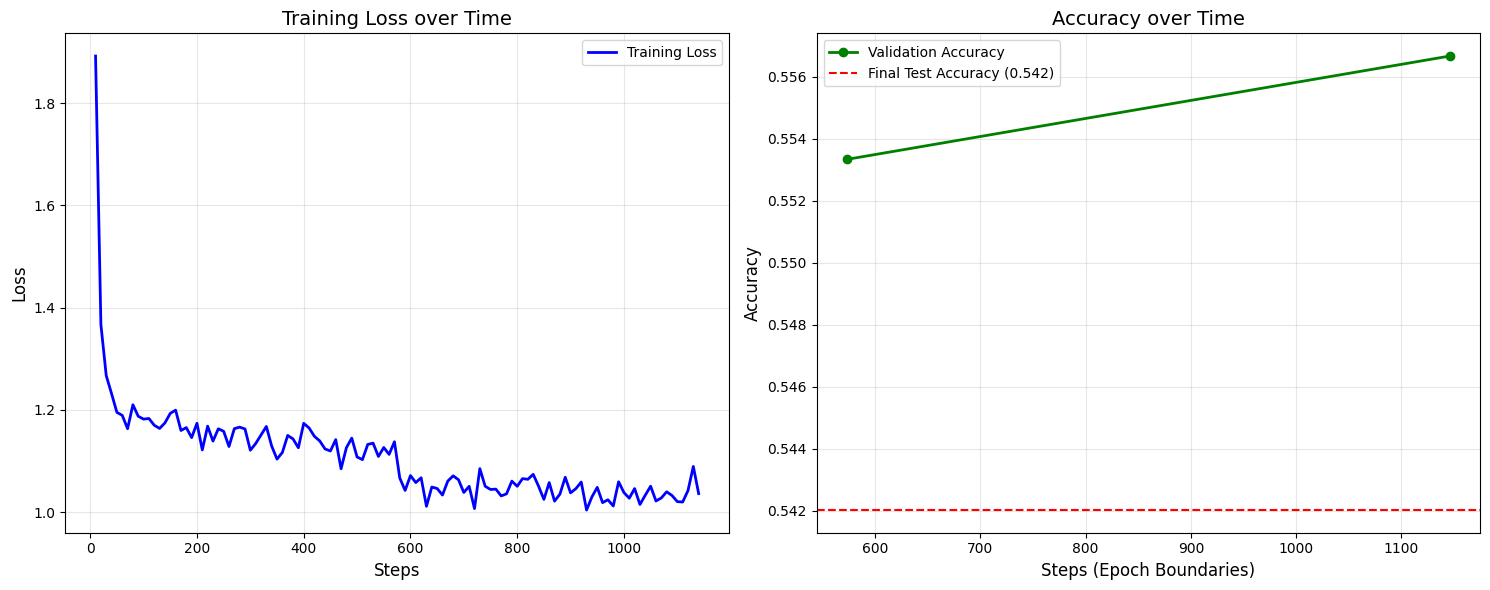

In [9]:
FastLanguageModel.for_inference(model)

true_labels = []
predictions = []

print("Evaluating on Complete Test Set...")
for sample in tqdm(dataset["test"]):

    # Recreate the prompt without the target answer
    opts = sample['options']
    options_text = f"A: {opts.get('A', '')}\nB: {opts.get('B', '')}\nC: {opts.get('C', '')}\nD: {opts.get('D', '')}"
    prompt = (
        f"### Instruction:\nAnswer the following multiple-choice medical question. Provide only the letter of the correct option (A, B, C, or D).\n\n"
        f"### Question:\n{sample['question']}\n\n"
        f"### Options:\n{options_text}\n\n"
        f"### Answer:\n"
    )

    inputs = tokenizer([prompt], return_tensors="pt").to("cuda")

    # Generate prediction
    outputs = model.generate(
        **inputs,
        max_new_tokens=2,
        use_cache=True,
        pad_token_id=tokenizer.eos_token_id,
        temperature=0.1
    )

    decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]
    predicted_answer = decoded.split("### Answer:\n")[-1].strip()[0:1].upper()

    true_labels.append(sample["answer_idx"].upper())
    predictions.append(predicted_answer)

acc = accuracy_score(true_labels, predictions)
f1_mac = f1_score(true_labels, predictions, average="macro")

print("\n" + "="*40)
print("     FINAL TEST SET EVALUATION")
print("="*40)
print(f"Test Accuracy: {acc:.4f}")
print(f"Test Macro F1: {f1_mac:.4f}")
print("="*40 + "\n")


# --- 2. Plot Training Loss and Validation Metrics ---
history = trainer.state.log_history

train_loss = [x['loss'] for x in history if 'loss' in x]
train_steps = [x['step'] for x in history if 'loss' in x]

val_acc = [x['val_accuracy'] for x in history if 'val_accuracy' in x]
val_steps = [x['step'] for x in history if 'val_accuracy' in x]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Training Loss
ax1.plot(train_steps, train_loss, label='Training Loss', color='blue', linewidth=2)
ax1.set_title('Training Loss over Time', fontsize=14)
ax1.set_xlabel('Steps', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Validation & Test Accuracy
if len(val_acc) > 0:
    ax2.plot(val_steps, val_acc, label='Validation Accuracy', color='green', marker='o', linewidth=2)
ax2.axhline(y=acc, color='red', linestyle='--', label=f"Final Test Accuracy ({acc:.3f})")
ax2.set_title('Accuracy over Time', fontsize=14)
ax2.set_xlabel('Steps (Epoch Boundaries)', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
notebook_end_time = time.time()
elapsed = notebook_end_time - notebook_start_time
hours, rem = divmod(elapsed, 3600)
minutes, seconds = divmod(rem, 60)
print(f"Total notebook execution time: {int(hours):02d}:{int(minutes):02d}:{int(seconds):02d}")


In [ ]:
if PUSH_TO_HUB:
    model.push_to_hub(config.HUB_REPO_ID, token=True)
    tokenizer.push_to_hub(config.HUB_REPO_ID, token=True)

README.md:   0%|          | 0.00/570 [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors: 100%|##########|  131MB /  131MB            

Saved model to https://huggingface.co/alexd063/gemma4bit-finetuned-medqa


Unsloth: Restored added_tokens_decoder metadata in /tmp/tmpzlrwisjo/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in /tmp/tmpzlrwisjo.


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...pzlrwisjo/tokenizer.model: 100%|##########| 4.69MB / 4.69MB            

  ...mpzlrwisjo/tokenizer.json: 100%|##########| 33.4MB / 33.4MB            